# Feature Engineering: Advanced Missing Data Techniques
### Random Sample Imputation, Missing Indicator, and Automated Tuning with GridSearchCV

---

### Scope & Focus of This Notebook
- **Primary Topic**: Advanced Missing Data Techniques — preserving distribution spread, capturing informative missingness, and automating strategy selection.
- **What You Will Learn**:
  1. What **Random Sample Imputation** is and why it preserves the natural variance and spread of a column.
  2. The **Covariance Drawback**: How random sampling can distort relationships between different columns.
  3. **Missing Indicator**: Why imputation causes models to forget that a value was originally missing, and how an extra binary ($0/1$) flag solves this.
  4. Informative Missingness (MNAR): Proving that Titanic passengers with missing ages had a significantly different survival rate.
  5. Scikit-Learn implementation using `SimpleImputer(add_indicator=True)` and standalone `MissingIndicator`.
  6. Automated Imputation Tuning: Using `GridSearchCV` on a `Pipeline` to scientifically test `strategy=['mean', 'median']` and `add_indicator=[True, False]` without manual guesswork.
  7. Understanding Scikit-Learn pipeline syntax (`imputer__strategy`), 5-Fold Cross-Validation (`cv=5`), and reading `grid.best_params_`.
- **What We Will NOT Cover Here**:
  - Foundational univariate Mean, Median, and Mode imputation were taught in **`11_Handling_Missing_Numerical_Data`** and **`12_Handling_Missing_Categorical_Data`**.
  - Multivariate imputation algorithms (KNNImputer, MICE / IterativeImputer) belong to subsequent dedicated modules.

---

## 1. Setup & Environment Verification

### What are we doing?
We import data manipulation, visualization, and machine learning libraries, and load the Titanic dataset with simple path checking.

#### What do these libraries do here?
- `pandas`: Tabular data structures and missing value manipulation (`.sample()`, `.isnull()`).
- `numpy`: Numerical calculations and handling `np.nan`.
- `matplotlib.pyplot` & `seaborn`: Plotting KDE distributions and bar charts before and after imputation.
- `sklearn`: Preprocessing (`SimpleImputer`, `Pipeline`), model tuning (`GridSearchCV`), and classification (`RandomForestClassifier`).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer, MissingIndicator
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Clean visualization settings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'

# Load Titanic dataset with fallback path
data_path = '../../data/titanic.csv' if os.path.exists('../../data/titanic.csv') else 'data/titanic.csv'
df = pd.read_csv(data_path)

print(f"Loaded Titanic Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Missing values in Age:  {df['Age'].isnull().sum()} out of {len(df)} rows")


Loaded Titanic Dataset: 891 rows, 12 columns
Missing values in Age:  177 out of 891 rows


## 2. Manual Understanding on a Simple Toy Dataset

### What are we doing?
Before working with the full Titanic dataset, we create a tiny 5-row table to see how **Random Sample Imputation** and **Missing Indicator** work line by line.

#### The Toy Data:
`Age = [20, 25, 30, 35, NaN]`


In [2]:
# 1. Create simple toy DataFrame
toy = pd.DataFrame({
    'Age': [20.0, 25.0, 30.0, 35.0, np.nan]
})

print("--- Original Toy Data ---")
print(toy)

# 2. Mean Imputation: Fills 27.5
toy['Age_Mean'] = toy['Age'].fillna(toy['Age'].mean())

# 3. Random Sample Imputation: Randomly draws one of the observed values [20, 25, 30, 35]
observed_values = toy['Age'].dropna()
random_pick = observed_values.sample(1, random_state=42).values[0]
toy['Age_Random'] = toy['Age'].fillna(random_pick)

# 4. Missing Indicator: Creates a binary flag (0 = observed, 1 = missing)
toy['Age_Was_Missing'] = toy['Age'].isnull().astype(int)

print("\n--- Toy Data After Advanced Transformations ---")
print(toy)


--- Original Toy Data ---
    Age
0  20.0
1  25.0
2  30.0
3  35.0
4   NaN

--- Toy Data After Advanced Transformations ---
    Age  Age_Mean  Age_Random  Age_Was_Missing
0  20.0      20.0        20.0                0
1  25.0      25.0        25.0                0
2  30.0      30.0        30.0                0
3  35.0      35.0        35.0                0
4   NaN      27.5        25.0                1


## 3. Implementing Random Sample Imputation on Titanic `Age`

### What are we doing?
In the Titanic dataset, `Age` has 177 missing values.
We implement Random Sample Imputation using 3 clean lines of pandas code:
1. Extract all observed (non-null) ages.
2. Draw 177 random samples with replacement using `.sample(177, random_state=42)`.
3. Align the sampled values with the index of the missing rows and fill them in.


In [3]:
# 1. Extract observed ages
observed_ages = df['Age'].dropna()

# 2. Draw 177 random samples with a fixed random_state for reproducibility
random_samples = observed_ages.sample(df['Age'].isnull().sum(), random_state=42)

# 3. Set the index of the samples to match the missing rows
random_samples.index = df[df['Age'].isnull()].index

# 4. Create the new imputed column
df['Age_Random'] = df['Age'].copy()
df['Age_Random'].loc[df['Age'].isnull()] = random_samples

# Create Mean Imputed column for direct comparison
df['Age_Mean'] = df['Age'].fillna(df['Age'].mean())

print("--- Sample Imputed Values (Showing previously missing rows) ---")
print(df[['Age', 'Age_Random', 'Age_Mean']].loc[df['Age'].isnull()].head(6))


--- Sample Imputed Values (Showing previously missing rows) ---
    Age  Age_Random   Age_Mean
5   NaN        42.0  29.699118
17  NaN         3.0  29.699118
19  NaN        29.0  29.699118
26  NaN        24.0  29.699118
28  NaN        43.0  29.699118
29  NaN         8.0  29.699118


## 4. Comparing Spread: Why Random Sampling Preserves Variance

### What are we doing?
We calculate the variance of `Age` under both strategies:
- **Original Variance**: 211.02
- **Mean Imputation**: Artificially deflates variance because all 177 missing entries are given the exact same number (29.70).
- **Random Sample Imputation**: Preserves natural variance because values are drawn from the real empirical distribution!


In [4]:
var_orig = df['Age'].var()
var_mean = df['Age_Mean'].var()
var_rand = df['Age_Random'].var()

print(f"Original Age Variance:        {var_orig:.2f}")
print(f"Mean Imputed Variance:        {var_mean:.2f}  (Lost {((var_orig - var_mean)/var_orig * 100):.1f}% variance!)")
print(f"Random Sample Age Variance:   {var_rand:.2f}  (Preserved {((var_rand/var_orig) * 100):.1f}% of variance!)")


Original Age Variance:        211.02
Mean Imputed Variance:        169.05  (Lost 19.9% variance!)
Random Sample Age Variance:   204.36  (Preserved 96.8% of variance!)


### Visualizing Distribution Preservation with Seaborn

### What are we doing?
We plot Kernel Density Estimation (KDE) curves comparing:
1. **Original Age** (Black solid curve)
2. **Mean Imputed Age** (Blue dashed curve $\to$ unnatural artificial peak at 29.7)
3. **Random Sample Imputed Age** (Green dotted curve $\to$ naturally hugs the original curve!)


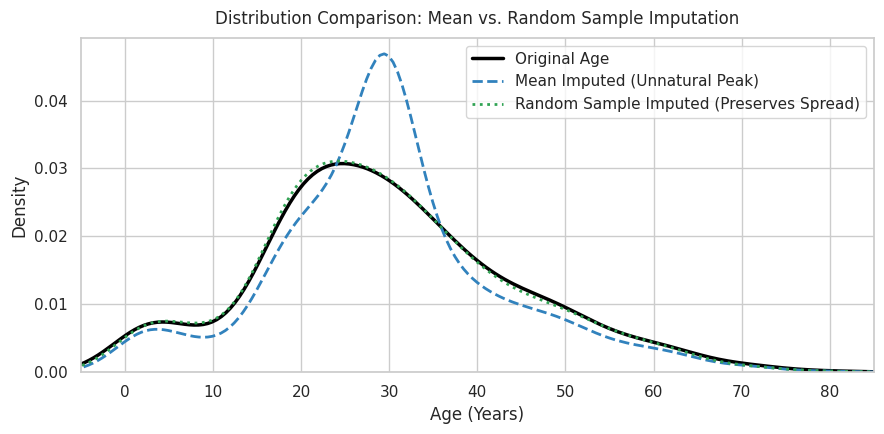

In [5]:
plt.figure(figsize=(9, 4.5))

sns.kdeplot(df['Age'], label='Original Age', color='black', linewidth=2.5)
sns.kdeplot(df['Age_Mean'], label='Mean Imputed (Unnatural Peak)', color='#3182bd', linewidth=2, linestyle='--')
sns.kdeplot(df['Age_Random'], label='Random Sample Imputed (Preserves Spread)', color='#31a354', linewidth=2, linestyle=':')

plt.title('Distribution Comparison: Mean vs. Random Sample Imputation', fontsize=12, pad=10)
plt.xlabel('Age (Years)')
plt.ylabel('Density')
plt.xlim(-5, 85)
plt.legend()
plt.tight_layout()
plt.show()


## 5. The Downside: Covariance and Correlation Distortion

### What are we doing?
Random Sample Imputation preserves the spread of a **single column**, but it completely ignores other columns in that row.
We check what happened to the relationship between `Age` and `Fare`.

#### What does the output mean?
Because we randomly paired ages with fares, the covariance drops from $73.85$ down to $60.59$.
Random sampling preserves the **univariate shape**, but slightly weakens **multivariate relationships**.


In [6]:
cov_orig = df['Age'].cov(df['Fare'])
cov_rand = df['Age_Random'].cov(df['Fare'])

corr_orig = df['Age'].corr(df['Fare'])
corr_rand = df['Age_Random'].corr(df['Fare'])

print("--- Covariance with Fare ---")
print(f"Original Age & Fare Covariance:         {cov_orig:.2f}")
print(f"Random Sample Age & Fare Covariance:    {cov_rand:.2f}")

print("\n--- Pearson Correlation (r) with Fare ---")
print(f"Original Correlation:                   {corr_orig:.4f}")
print(f"Random Sample Correlation:              {corr_rand:.4f}")


--- Covariance with Fare ---
Original Age & Fare Covariance:         73.85
Random Sample Age & Fare Covariance:    68.63

--- Pearson Correlation (r) with Fare ---
Original Correlation:                   0.0961
Random Sample Correlation:              0.0966


## 6. The Missing Indicator: Capturing Informative Missingness

### What are we doing?
When we fill missing values with a number, the model forgets which values were originally missing.
We add a companion binary column:
```python
df['Age_NA'] = df['Age'].isnull().astype(int)
```
- `0`: Age was known.
- `1`: Age was missing and imputed.

#### Testing If Missingness Carries Predictive Signal:
Let's check the survival rate of passengers whose Age was recorded vs. those whose Age was missing!


In [7]:
# 1. Create the Missing Indicator column
df['Age_NA'] = df['Age'].isnull().astype(int)

# 2. Compare survival rates
indicator_survival = df.groupby('Age_NA')['Survived'].agg(
    Passenger_Count='count',
    Survival_Rate=lambda s: round(s.mean() * 100, 1)
)
indicator_survival.index = ['Age Known (0)', 'Age Missing (1)']

print("--- Survival Rate by Missingness Indicator ---")
print(indicator_survival)


--- Survival Rate by Missingness Indicator ---
                 Passenger_Count  Survival_Rate
Age Known (0)                714           40.6
Age Missing (1)              177           29.4


### The Revelation of the Missing Indicator

#### What did the data reveal?
- Passengers with **known age** had a **40.6%** survival rate.
- Passengers with **missing age** had only a **29.4%** survival rate!

Why? Because 3rd-class passengers had far more missing age records than 1st-class passengers.
Missingness was **not completely random** — it carried a genuine predictive signal.
Adding `Age_NA = 1` provides this signal to the machine learning model!


## 7. Scikit-Learn: `SimpleImputer(add_indicator=True)`

### Meaningful Function Explanation: `SimpleImputer(strategy='median', add_indicator=True)`

1. **What is this function?**  
   Scikit-Learn's built-in parameter that simultaneously fills missing values AND appends binary indicator columns.
2. **Why did we use it?**  
   It eliminates the need to manually compute `.isnull().astype(int)` by automating indicator creation inside standard preprocessing.
3. **What does it take as input?**  
   - `strategy`: How to fill values (`'mean'`, `'median'`, etc.).
   - `add_indicator=True`: Automatically appends an extra binary column for every feature that contained nulls.
4. **What does it return?**  
   A transformed 2D array containing the imputed feature columns PLUS the binary indicator flags.
5. **How does it work internally?**  
   - During `fit(X_train)`: Detects which features contain `np.nan`.
   - During `transform(X)`: Fills `np.nan` with the strategy and appends $0/1$ boolean masks.
6. **Why did we choose this approach?**  
   It avoids manual data manipulation and guarantees zero data leakage during cross-validation.
7. **What will happen if we don't use it?**  
   We would have to write manual pandas indicator functions and maintain them across training and test sets.
8. **Concrete Before / After Example:**  
   - Input: `Age` column with `[25, NaN, 35]`  
   - Output: 2 columns $\implies$ Column 1: `[25, 30, 35]` (Imputed), Column 2: `[0, 1, 0]` (Indicator).


In [8]:
# Using SimpleImputer with add_indicator=True
imputer_with_ind = SimpleImputer(strategy='median', add_indicator=True)

sample_data = df[['Age', 'Fare']].head(6)
imputed_array = imputer_with_ind.fit_transform(sample_data)

# Display the output as a clean DataFrame
feature_names = ['Age_Imputed', 'Fare', 'Age_Was_Missing_Flag']
imputed_df = pd.DataFrame(imputed_array, columns=feature_names)

print("--- Scikit-Learn Automated Indicator Output ---")
print(imputed_df)


--- Scikit-Learn Automated Indicator Output ---
   Age_Imputed     Fare  Age_Was_Missing_Flag
0         22.0   7.2500                   0.0
1         38.0  71.2833                   0.0
2         26.0   7.9250                   0.0
3         35.0  53.1000                   0.0
4         35.0   8.0500                   0.0
5         35.0   8.4583                   1.0


## 8. Automated Imputation Tuning with `GridSearchCV`

### What are we doing?
Instead of guessing whether to use `mean` or `median`, and guessing whether `add_indicator` helps or hurts, we let **GridSearchCV** find the best combination empirically.

#### Why Do We Put It in a Pipeline?
```text
Data ──► Imputation Step ──► Model Step
```
Using a `Pipeline` ensures that during each cross-validation fold, the imputer is fit **strictly on the training fold** and evaluated on the validation fold (zero leakage).

#### What Does `'imputer__strategy'` Mean?
In Scikit-Learn, double underscores (`__`) connect the **step name** (`'imputer'`) to its **parameter name** (`'strategy'`).


In [9]:
# 1. Select features and target
features = ['Pclass', 'Age', 'Fare', 'SibSp', 'Parch']
target = 'Survived'

X = df[features]
y = df[target]

# 2. Split into Train (80%) and Test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Create a clean Pipeline
pipe = Pipeline([
    ('imputer', SimpleImputer()),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42))
])

# 4. Define the Parameter Grid to test
param_grid = {
    'imputer__strategy': ['mean', 'median'],
    'imputer__add_indicator': [True, False]
}

print("Testing all 4 parameter combinations across 5-Fold Cross-Validation...")


Testing all 4 parameter combinations across 5-Fold Cross-Validation...


### Running the Grid Search

### What does `cv=5` mean?
The training data is split into 5 equal parts (folds). Each of the 4 parameter combinations is tested 5 times on unseen folds, for a total of $4 \times 5 = 20$ training runs!


In [10]:
# 5. Build and fit GridSearchCV
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

# 6. Display results
print("=" * 60)
print(f"Optimal Imputation Strategy:     {grid.best_params_['imputer__strategy']}")
print(f"Use Missing Indicator Flag:      {grid.best_params_['imputer__add_indicator']}")
print(f"Best Cross-Validation Accuracy:  {grid.best_score_ * 100:.2f}%")
print("=" * 60)

# Evaluate on unseen holdout test set
test_score = grid.score(X_test, y_test)
print(f"Final Unseen Test Accuracy:      {test_score * 100:.2f}%")


Optimal Imputation Strategy:     mean
Use Missing Indicator Flag:      True
Best Cross-Validation Accuracy:  75.15%
Final Unseen Test Accuracy:      70.95%


### Inspecting All Tested Combinations

### What are we doing?
We inspect `cv_results_` to see the exact cross-validation score achieved by each combination.


In [11]:
# Convert cv_results_ to a clean table
cv_summary = pd.DataFrame(grid.cv_results_)[
    ['param_imputer__strategy', 'param_imputer__add_indicator', 'mean_test_score', 'rank_test_score']
].sort_values(by='rank_test_score')

cv_summary.columns = ['Strategy', 'Add_Indicator', 'Mean_CV_Accuracy', 'Rank']
cv_summary['Mean_CV_Accuracy'] = (cv_summary['Mean_CV_Accuracy'] * 100).round(2)

print("--- Complete GridSearchCV Ranking Table ---")
print(cv_summary)


--- Complete GridSearchCV Ranking Table ---
  Strategy  Add_Indicator  Mean_CV_Accuracy  Rank
0     mean           True             75.15     1
1   median           True             75.15     1
3   median          False             74.02     3
2     mean          False             73.74     4


---

## What We Learned
- **Random Sample Imputation**:
  - Replaces missing values by randomly drawing from observed non-null values in the same column.
  - **Preserves univariate spread**: Variance remains almost identical to original data (no artificial spikes at the mean).
  - **Drawback**: Ignores inter-feature relationships and can weaken covariance with other columns.
- **Missing Indicator**:
  - Adds an extra binary ($0/1$) flag column indicating whether the original value was missing.
  - Solves the problem of models confusing imputed estimates with genuine real measurements.
  - Crucial when missingness is informative (MNAR), such as Titanic 3rd class passengers having higher missingness rates.
  - **Important**: The indicator does *not* replace the missing value; it is used *together* with an imputer.
- **Automated Imputation Tuning with GridSearchCV**:
  - Uses cross-validation to scientifically compare combinations of imputation strategies (`strategy=['mean', 'median']`) and indicator flags (`add_indicator=[True, False]`).
  - Uses double underscores (`imputer__strategy`) to target transformer parameters inside a `Pipeline`.
  - Guarantees zero data leakage by fitting imputers strictly inside training folds.

---

## Important Takeaways
1. **Always set `random_state` for Random Sample Imputation**: Otherwise, imputed values will change randomly on every code run.
2. **Missing Indicator + Imputation is a powerful team**: One fills the cell so models don't crash, while the other reminds the model that the value was absent.
3. **Use GridSearchCV instead of guessing**: Let 5-fold cross-validation tell you whether mean, median, or indicators actually improve validation accuracy.
4. **Check covariance when using Random Sampling**: If your model relies heavily on feature correlations (like linear regression), random sampling may dilute those relationships.

---

## Common Mistakes
1. **Thinking an indicator fills missing values**: An indicator only creates a `0/1` column; the original column still has nulls that must be imputed!
2. **Fitting GridSearchCV on the test set**: Always fit grid search strictly on `X_train`.
3. **Using double underscores incorrectly**: Remember that `stepname__parametername` requires two underscores (`__`), not one.
4. **Assuming the most complex strategy is always best**: Sometimes simple median imputation without an indicator wins on validation scores. Let the data decide!

---

## Final Mental Model

```text
                        Missing Value Encountered (NaN)
                                       │
                ┌──────────────────────┼──────────────────────┐
                ▼                      ▼                      ▼
        "How do I fill it?"    "Does missingness     "Which method
                                  carry signal?"        is best?"
                │                      │                      │
                ▼                      ▼                      ▼
       Mean / Median /         Add a Missing             Use
        Random Sample            Indicator           GridSearchCV
        (Replace NaN)          (0/1 Flag)            (Tune Choice)
```
